In [3]:
import choix
import pandas as pd
import json
import ast
from enum import Enum
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from itertools import permutations
import itertools
from collections import Counter
from dataclasses import dataclass

In [4]:
class SpeakerType(Enum):
    HUMAN = "human"
    BASE = "base"
    MAS = "mas"
    MAS_RAG = "mas_rag"

class ModelName(Enum):
    NO_MODEL = ""
    GPT_4O_MINI = "gpt-4o-mini"
    GPT_5 = "gpt-5"
    GPT_4O = "gpt-4o"
    GROK_3 = "grok-3"
    GROK_4 = "grok-4"
    MISTRAL_MEDIUM = "mistral-medium"
    

class PoliticalPosition(Enum):
    LEFT = "l"
    RIGHT = "r"

In [5]:
models = []

for name, model in ModelName.__members__.items():
    if name != "NO_MODEL" and name != "GPT_5" and name != "GPT_4O_MINI" and name != "GROK_4":
        for model_type_name, model_type in SpeakerType.__members__.items():
            if model_type_name != "HUMAN":
                #print(model.value+"_"+model_type.value)
                models.append(model.value+"_"+model_type.value)
models

['gpt-4o_base',
 'gpt-4o_mas',
 'gpt-4o_mas_rag',
 'grok-3_base',
 'grok-3_mas',
 'grok-3_mas_rag',
 'mistral-medium_base',
 'mistral-medium_mas',
 'mistral-medium_mas_rag']

In [6]:
results_df = pd.read_csv("data/all-debates.csv", sep="|")

In [7]:
results_df.head()

,Unnamed: 0,loser,winner,session_id,debate_topic,next_speaker,first_speaker,second_speaker,current_speaker,dialogue_history,...,max_sentences,speaker_order,original_claim,opponents_utterance,opponent_speaker_name,opponents_commitments,opponents_original_claim,utterance_with_corresponding_types,typical_replies_for_last_speakers_response,opponents_utterance_with_corresponding_types
0,0,NaN,NaN,gpt-4o_base:l__vs__grok-3_base:r,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,grok-3_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,gpt-4o_base:l__vs__mistral-medium_base:r,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,mistral-medium_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,grok-3_base,gpt-4o_base,gpt-4o_base:r__vs__grok-3_base:l,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,grok-3_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'sentences_with_ut...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,gpt-4o_base:r__vs__mistral-medium_base:l,Debate the trade-offs of government interventi...,second_speaker,gpt-4o_base,mistral-medium_base,first_speaker,"[{'speaker': 'gpt-4o_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,grok-3_base:l__vs__gpt-4o_base:r,Debate the trade-offs of government interventi...,second_speaker,grok-3_base,gpt-4o_base,first_speaker,"[{'speaker': 'grok-3_base', 'timestamp': '2025...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
mistral = ['mistral-medium_base',
 'mistral-medium_mas',
 'mistral-medium_mas_rag']

In [59]:
speakers = []
speakers.extend(results_df["first_speaker"].unique().tolist())
speakers.extend(results_df["second_speaker"].unique().tolist())
speakers = list(set(speakers))
for m in mistral:
    speakers.remove(m)
sorted(speakers)

['gpt-4o_base',
 'gpt-4o_mas',
 'gpt-4o_mas_rag',
 'grok-3_base',
 'grok-3_mas',
 'grok-3_mas_rag',
 'human_1',
 'human_10',
 'human_11',
 'human_12',
 'human_13',
 'human_2',
 'human_3',
 'human_4',
 'human_5',
 'human_6',
 'human_7',
 'human_8',
 'human_9']

In [61]:
pairs = []

for idx, row in results_df.iterrows():
    if row["first_speaker"] not in mistral and row["second_speaker"] not in mistral:
        pairs.append((row["first_speaker"], row["second_speaker"]))

print(pairs)

[('gpt-4o_base', 'grok-3_base'), ('gpt-4o_base', 'grok-3_base'), ('grok-3_base', 'gpt-4o_base'), ('grok-3_base', 'gpt-4o_base'), ('gpt-4o_base', 'gpt-4o_mas'), ('gpt-4o_base', 'grok-3_mas'), ('gpt-4o_base', 'gpt-4o_mas'), ('gpt-4o_base', 'grok-3_mas'), ('grok-3_base', 'gpt-4o_mas'), ('grok-3_base', 'grok-3_mas'), ('grok-3_base', 'gpt-4o_mas'), ('grok-3_base', 'grok-3_mas'), ('gpt-4o_base', 'gpt-4o_mas_rag'), ('gpt-4o_base', 'grok-3_mas_rag'), ('gpt-4o_base', 'gpt-4o_mas_rag'), ('gpt-4o_base', 'grok-3_mas_rag'), ('grok-3_base', 'gpt-4o_mas_rag'), ('grok-3_base', 'grok-3_mas_rag'), ('grok-3_base', 'gpt-4o_mas_rag'), ('grok-3_base', 'grok-3_mas_rag'), ('gpt-4o_mas', 'gpt-4o_base'), ('gpt-4o_mas', 'grok-3_base'), ('gpt-4o_mas', 'gpt-4o_base'), ('gpt-4o_mas', 'grok-3_base'), ('grok-3_mas', 'gpt-4o_base'), ('grok-3_mas', 'grok-3_base'), ('grok-3_mas', 'gpt-4o_base'), ('grok-3_mas', 'grok-3_base'), ('gpt-4o_mas', 'grok-3_mas'), ('gpt-4o_mas', 'grok-3_mas'), ('grok-3_mas', 'gpt-4o_mas'), ('gro

In [62]:
counts = Counter(pairs)

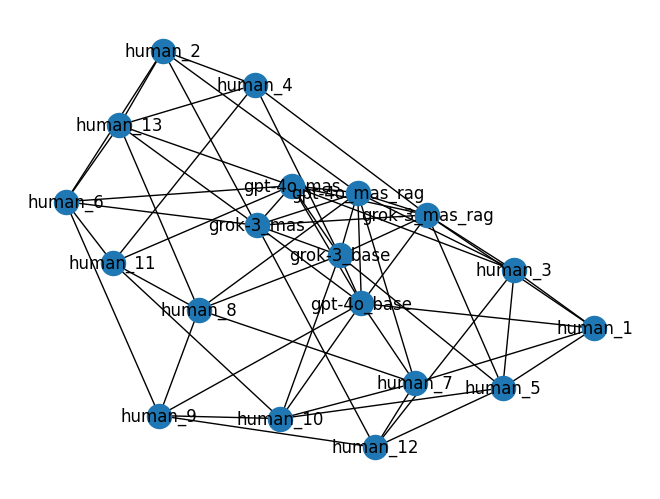

In [63]:
G = nx.Graph()
for (u, v), weight in counts.items():
    G.add_edge(u, v, weight=weight)

nx.draw(G, with_labels=True)

In [64]:
nodelist = list(G.nodes)
A = nx.to_numpy_array(G, nodelist=nodelist)

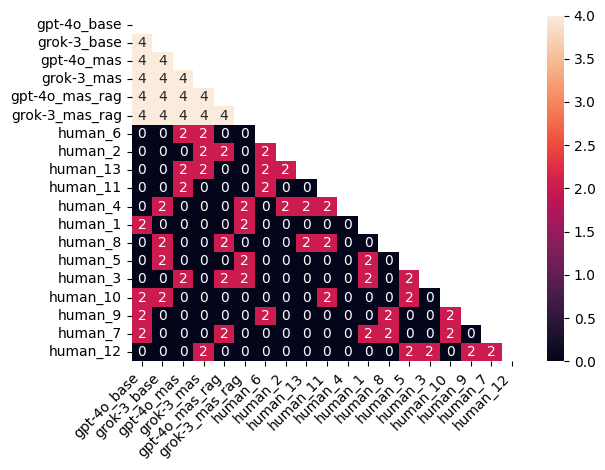

In [65]:
mask = np.triu(np.ones_like(A, dtype=bool))

sns.heatmap(2*A, xticklabels=nodelist, yticklabels=nodelist, annot=True, fmt=".0f", mask=mask)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

In [66]:
n = len(nodelist)
n_log_n = n * np.log(n)
print(f"n = {n}, n ln n = {n_log_n:.2f}")

n = 19, n ln n = 55.94


In [67]:
num_pairs = n * (n - 1) // 2

print(f"Pairs: {num_pairs}")

Pairs: 171


## Win Matrix

In [70]:
speaker_to_idx = {speaker: idx for idx, speaker in enumerate(nodelist)}

n = len(nodelist)
W = np.zeros((n, n))

for idx, row in results_df.iterrows():
    if row["first_speaker"] not in mistral and row["second_speaker"] not in mistral:
        i = speaker_to_idx[row["first_speaker"]]
        j = speaker_to_idx[row["second_speaker"]]
        winner = row["winner"] 

        if winner == row["first_speaker"]:
            W[i][j] += 1
        elif winner == row["second_speaker"]:
            W[j][i] += 1
        else:
            W[i][j] += 0.5
            W[j][i] += 0.5

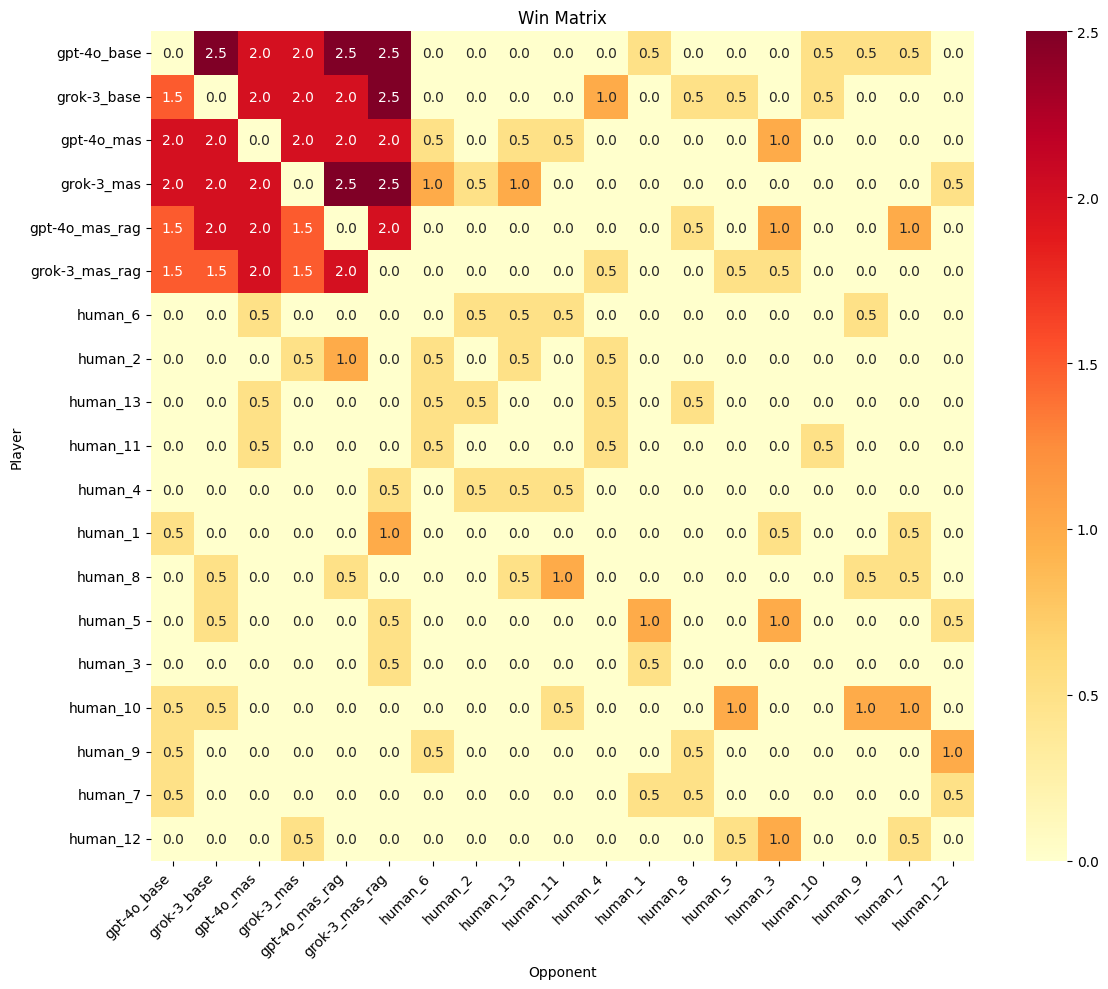

In [71]:
plt.figure(figsize=(12, 10))
sns.heatmap(W, xticklabels=nodelist, yticklabels=nodelist, annot=True, fmt=".1f", cmap="YlOrRd")
plt.xlabel("Opponent")
plt.ylabel("Player")
plt.title("Win Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [72]:
W

array([[0. , 2.5, 2. , 2. , 2.5, 2.5, 0. , 0. , 0. , 0. , 0. , 0.5, 0. ,
        0. , 0. , 0.5, 0.5, 0.5, 0. ],
       [1.5, 0. , 2. , 2. , 2. , 2.5, 0. , 0. , 0. , 0. , 1. , 0. , 0.5,
        0.5, 0. , 0.5, 0. , 0. , 0. ],
       [2. , 2. , 0. , 2. , 2. , 2. , 0.5, 0. , 0.5, 0.5, 0. , 0. , 0. ,
        0. , 1. , 0. , 0. , 0. , 0. ],
       [2. , 2. , 2. , 0. , 2.5, 2.5, 1. , 0.5, 1. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0.5],
       [1.5, 2. , 2. , 1.5, 0. , 2. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5,
        0. , 1. , 0. , 0. , 1. , 0. ],
       [1.5, 1.5, 2. , 1.5, 2. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. ,
        0.5, 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0. , 0. , 0. , 0. , 0.5, 0.5, 0.5, 0. , 0. , 0. ,
        0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0.5, 1. , 0. , 0.5, 0. , 0.5, 0. , 0.5, 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0. , 0. , 0. , 0.5, 0.5, 0. , 0. , 0.5, 0. , 0.5,
        0. , 0. , 0. , 0. , 0. 

In [89]:
# Convert win matrix to pairwise comparison data for choix
params = choix.ilsr_pairwise_dense(W, alpha=0.01)

# Convert to DataFrame for readability
rankings = pd.DataFrame({
    "speaker": nodelist,
    "score": params
}).sort_values("score", ascending=False).reset_index(drop=True)

print(rankings)

           speaker     score
0         human_10  0.976378
1       grok-3_mas  0.437828
2      gpt-4o_base  0.393358
3          human_2  0.324516
4      grok-3_base  0.271876
5          human_8  0.271233
6          human_5  0.239648
7          human_9  0.238200
8       gpt-4o_mas  0.171264
9   gpt-4o_mas_rag  0.054917
10        human_12 -0.136015
11  grok-3_mas_rag -0.180655
12         human_6 -0.180902
13        human_13 -0.195982
14        human_11 -0.209129
15         human_1 -0.225106
16         human_4 -0.351502
17         human_7 -0.438489
18         human_3 -1.461437


In [90]:
comparisons = []

for idx, row in results_df.iterrows():
    if row["first_speaker"] not in mistral and row["second_speaker"] not in mistral:
        winner = row["winner"]

        if winner == row["first_speaker"]:
            comparisons.append((speaker_to_idx[row["first_speaker"]], speaker_to_idx[row["second_speaker"]]))
        elif winner == row["second_speaker"]:
            comparisons.append((speaker_to_idx[row["second_speaker"]], speaker_to_idx[row["first_speaker"]]))

params = choix.ilsr_pairwise(n, comparisons, alpha=0.01)

In [91]:
rankings = pd.DataFrame({
    "speaker": nodelist,
    "score": params
}).sort_values("score", ascending=False).reset_index(drop=True)

print(rankings)

           speaker     score
0         human_10  2.007689
1      gpt-4o_base  1.847550
2       grok-3_mas  1.796867
3          human_8  1.279068
4          human_2  1.206677
5          human_5  0.995901
6      grok-3_base  0.845741
7          human_9  0.686416
8          human_1  0.206517
9          human_6 -0.223552
10        human_13 -0.223552
11        human_11 -0.555617
12      gpt-4o_mas -0.588741
13        human_12 -0.688865
14  gpt-4o_mas_rag -0.835962
15         human_4 -0.873744
16  grok-3_mas_rag -0.977045
17         human_7 -2.420835
18         human_3 -3.484512
